## Machine Learning Pipeline

As the class practice, the students will be required to develop a machine learning pipeline using the `Churn_Modelling_train_test.csv` dataset.

**About dataset**

This dataset is obained from [kaggle](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction?resource=download). It contains information on bank customers who either left the bank or continue to be a customer. The dataset includes the following attributes:

* Customer ID: A unique identifier for each customer
* Surname: The customer's surname or last name
* Credit Score: A numerical value representing the customer's credit score
* Geography: The country where the customer resides (France, Spain or Germany)
* Gender: The customer's gender (Male or Female)
* Age: The customer's age.
* Tenure: The number of years the customer has been with the bank
* Balance: The customer's account balance
* NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)
* HasCrCard: Whether the customer has a credit card (1 = yes, 0 = no)
* IsActiveMember: Whether the customer is an active member (1 = yes, 0 = no)
* EstimatedSalary: The estimated salary of the customer
* Exited: Whether the customer has churned (1 = yes, 0 = no)


### Exploratory Data Analysis

In this section the students are required to do an EDA to understand the dataset.

In [71]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import mlflow


In [72]:
# Load the dataset

df = pd.read_csv("Churn_Modelling_train_test.csv") 
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,4784,15729224,Jennings,710,France,Female,37.0,5,0.00,2,1.0,0.0,115403.31,0
1,1497,15799156,Okwuadigbo,569,Spain,Male,38.0,8,0.00,2,0.0,0.0,79618.79,0
2,1958,15674922,Beavers,710,France,Male,54.0,6,171137.62,1,1.0,1.0,167023.95,1
3,9174,15653572,Thornton,673,Spain,Male,43.0,8,127132.96,1,0.0,1.0,6009.27,1
4,9748,15775761,Iweobiegbunam,610,Germany,Female,69.0,5,86038.21,3,0.0,0.0,192743.06,1


In [73]:
# dataset analysis
df.info()
df = df.drop(columns=["CustomerId", "Surname"])
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9001 non-null   int64  
 1   CustomerId       9001 non-null   int64  
 2   Surname          9001 non-null   object 
 3   CreditScore      9001 non-null   int64  
 4   Geography        9000 non-null   object 
 5   Gender           9001 non-null   object 
 6   Age              9000 non-null   float64
 7   Tenure           9001 non-null   int64  
 8   Balance          9001 non-null   float64
 9   NumOfProducts    9001 non-null   int64  
 10  HasCrCard        9000 non-null   float64
 11  IsActiveMember   9001 non-null   float64
 12  EstimatedSalary  9001 non-null   float64
 13  Exited           9001 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 984.6+ KB


RowNumber          0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [23]:
# review categorical variables
df["Geography"].value_counts()
df["Gender"].value_counts()

Gender
Male      4906
Female    4095
Name: count, dtype: int64

In [7]:
# review binary variables
df["Exited"].value_counts()
df["HasCrCard"].value_counts()
df["IsActiveMember"].value_counts()

IsActiveMember
1.0    4633
0.0    4368
Name: count, dtype: int64

In [9]:
# review numerical variables
df["CreditScore"].value_counts()
df["Balance"].value_counts()
df["Age"].value_counts()
df["Tenure"].value_counts()
df["EstimatedSalary"].value_counts()


EstimatedSalary
24924.92     2
38190.78     2
92888.52     2
115403.31    1
107067.37    1
            ..
137254.55    1
153356.80    1
3740.93      1
10842.46     1
53581.14     1
Name: count, Length: 8998, dtype: int64

**EDA Conclusions**

From this Exploratory Data Analysis we can retrieve the following information:
* *To be completed by the student*

### ML Pipeline

In this section the students are required to create a ML pipeline to predict whether the customer left the bank or not.

In [29]:
# import packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [26]:
# Load the dataset
df = pd.read_csv('/Users/shelciamuianga/Desktop/MLOPS/mlops-and-system-design/session_2/Churn_Modelling_train_test.csv')

In [48]:
# Preprocess the features - create a function or a class for it 
def transform(df):

    df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

    df = pd.get_dummies(
        df,
        columns=["Geography", "Gender"],
        drop_first=True
    )

    return df

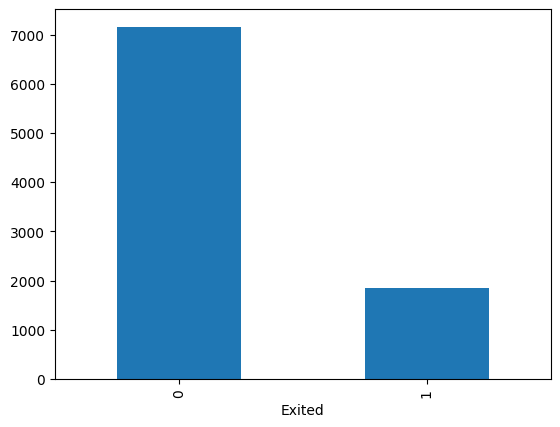

In [39]:
# balance the dataset (if you think it is necessary)
df["Exited"].value_counts().plot(kind="bar")
plt.show()


In [50]:
# Train a decision tree model using the `train sample`
DecisionTreeClassifier()   
df = transform(df) 
X = df.drop(columns=["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [52]:
# Check the accuracy of the model on the `test sample`
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: (accuracy)")

Accuracy: (accuracy)


### MLFlow Integration

In this section the students are required to track the model and the parameters into MLFlow.

In [74]:
import sys
!{sys.executable} -m pip install mlflow


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [75]:
# import packages for mlfow
import mlflow
from mlflow.models import infer_signature



Start a local Tracking server on port 8080 - it is necessary to import mlflow and open a new terminal

In [76]:
# Set our tracking server uri for logging on port 8080
mlflow.set_tracking_uri("http://127.0.0.1:8080")
print("Tracking URI: {}".format(mlflow.get_tracking_uri()))

Tracking URI: http://127.0.0.1:8080


Visit the MLFlow UI on `http://127.0.0.1:8080`

In [77]:
# Create a new MLflow Experiment called `Practice Experiment - {Your Name}`
mlflow.set_experiment("Practice Experiment - Shelcia")

2026/05/24 18:50:26 INFO mlflow.tracking.fluent: Experiment with name 'Practice Experiment - Shelcia' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/607637386112095231', creation_time=1779641426956, experiment_id='607637386112095231', last_update_time=1779641426956, lifecycle_stage='active', name='Practice Experiment - Shelcia', tags={}>

In [78]:
# Create a new MLflow Experiment
mlflow.set_experiment("Practice Experiment - Shelcia")

# Start an MLflow run
with mlflow.start_run():

    # Log hyperparameters
    mlflow.log_param("model_type", "DecisionTreeClassifier")

    # Log metric
    mlflow.log_metric("accuracy", accuracy)

    # Set a tag
    mlflow.set_tag(
        "Training Info",
        "Decision Tree model for bank churn prediction"
    )

    # Infer the model signature
    from mlflow.models.signature import infer_signature

    signature = infer_signature(
        X_train,
        model.predict(X_train)
    )

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="bank_model",
        signature=signature,
        input_example=X_train,
        registered_model_name="bank-model-decision-tree",
    )

/Users/shelciamuianga/Desktop/MLOPS/mlops-and-system-design/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Successfully registered model 'bank-model-decision-tree'.
2026/05/24 18:50:32 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Mo

🏃 View run placid-shrew-290 at: http://127.0.0.1:8080/#/experiments/607637386112095231/runs/a55be0e49475451ba7146098143f3dda
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/607637386112095231


Created version '1' of model 'bank-model-decision-tree'.


### Keep practicing

In [ ]:
# Create a new experiment using other models or different parameters
